<a href="https://colab.research.google.com/github/alchemist-sourav/Gridlock-Hackathon-2.0/blob/main/Gridlock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sample_submission.csv to sample_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv


In [ ]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

In [ ]:
print(train.shape)
print(test.shape)
print(sample.shape)


(77299, 11)
(41778, 10)
(5, 2)


In [ ]:
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [ ]:
test.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [ ]:
sample.head()

,Index,demand
0,0,0.090768
1,1,0.089885
2,2,0.007037
3,3,0.079087
4,4,0.054636


In [ ]:
train.columns
train.info()
train.isnull().sum()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [ ]:
train.isnull().sum()

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,600
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,2495


In [ ]:
for col in ['RoadType','LargeVehicles','Landmarks','Weather']:
    print("\n",col)
    print(train[col].value_counts(dropna=False))


 RoadType
RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
Name: count, dtype: int64

 LargeVehicles
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

 Landmarks
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

 Weather
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
Name: count, dtype: int64


In [ ]:
import pandas as pd

train['timestamp'] = pd.to_datetime(
    train['timestamp'],
    format='%H:%M'
)

train['hour'] = train['timestamp'].dt.hour

train.groupby('hour')['demand'].mean()

,demand
hour,
0,0.083369
1,0.089793
2,0.087368
3,0.091329
4,0.101678
5,0.104368
6,0.103913
7,0.106198
8,0.106149


In [ ]:
train.groupby('Weather')['demand'].mean()

,demand
Weather,
Foggy,0.093372
Rainy,0.094471
Snowy,0.092581
Sunny,0.094247


In [ ]:
train.groupby('RoadType')['demand'].mean()

,demand
RoadType,
Highway,0.610756
Residential,0.057209
Street,0.273164


In [ ]:
train.groupby('NumberofLanes')['demand'].mean()

,demand
NumberofLanes,
1,0.088104
2,0.077488
3,0.077859
4,0.602882
5,0.607556


In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
for col in ["RoadType","Weather"]:
    train[col] = train[col].fillna("Unknown")
    test[col] = test[col].fillna("Unknown")

train["Temperature"] = train["Temperature"].fillna(
    train["Temperature"].median()
)

test["Temperature"] = test["Temperature"].fillna(
    train["Temperature"].median()
)

train["RoadType"] = train["RoadType"].fillna("Unknown")
test["RoadType"] = test["RoadType"].fillna("Unknown")

In [ ]:
train["timestamp"] = pd.to_datetime(
    train["timestamp"],
    format="%H:%M"
)

test["timestamp"] = pd.to_datetime(
    test["timestamp"],
    format="%H:%M"
)

for df in [train,test]:
    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute

In [ ]:
X = train.drop(
    ["demand","timestamp"],
    axis=1
)

y = train["demand"]

X_test = test.drop(
    ["timestamp"],
    axis=1
)

In [ ]:
cat_features = [
    X.columns.get_loc("geohash"),
    X.columns.get_loc("RoadType"),
    X.columns.get_loc("LargeVehicles"),
    X.columns.get_loc("Landmarks"),
    X.columns.get_loc("Weather")
]

In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    verbose=100
)

model.fit(
    X,
    y,
    cat_features=cat_features
)

0:	learn: 0.1368950	total: 97ms	remaining: 1m 36s
100:	learn: 0.0429535	total: 4.13s	remaining: 36.8s
200:	learn: 0.0395783	total: 7.86s	remaining: 31.3s
300:	learn: 0.0374312	total: 12.3s	remaining: 28.6s
400:	learn: 0.0359293	total: 16.5s	remaining: 24.7s
500:	learn: 0.0346858	total: 21.2s	remaining: 21.2s
600:	learn: 0.0335880	total: 25.3s	remaining: 16.8s
700:	learn: 0.0327751	total: 29.2s	remaining: 12.5s
800:	learn: 0.0321015	total: 33.9s	remaining: 8.43s
900:	learn: 0.0315964	total: 38.1s	remaining: 4.18s
999:	learn: 0.0310563	total: 42.2s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [ ]:
preds = model.predict(X_test)

In [ ]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": preds
})

submission.to_csv(
    "submission_v1.csv",
    index=False
)

submission.head()

,Index,demand
0,0,0.031963
1,1,0.016530
2,2,0.002852
3,3,0.018269
4,4,0.031192


In [ ]:
from google.colab import files

files.download("submission_v1.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
for df in [train, test]:
    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute
    df["weekday"] = df["day"] % 7

    df["is_weekend"] = (
        df["weekday"] >= 5
    ).astype(int)

    df["rush_hour"] = (
        ((df["hour"] >= 7) & (df["hour"] <= 10))
        |
        ((df["hour"] >= 17) & (df["hour"] <= 20))
    ).astype(int)

In [ ]:
for df in [train, test]:

    df["temp_lane"] = (
        df["Temperature"] *
        df["NumberofLanes"]
    )

    df["landmark_lane"] = (
        df["Landmarks"].astype(str)
        + "_"
        + df["NumberofLanes"].astype(str)
    )

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
pred = model.predict(X_valid)

print(r2_score(y_valid, pred))

0.9544674906391546


In [ ]:
model = CatBoostRegressor(
    iterations=3000,
    depth=10,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="R2",
    verbose=200
)

In [ ]:
X = train.drop(
    ["Index","demand","timestamp"],
    axis=1
)

X_test = test.drop(
    ["Index","timestamp"],
    axis=1
)

In [ ]:
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

for col in ["RoadType","Weather"]:
    train[col] = train[col].fillna("Unknown")
    test[col] = test[col].fillna("Unknown")

train["Temperature"] = train["Temperature"].fillna(train["Temperature"].median())
test["Temperature"] = test["Temperature"].fillna(train["Temperature"].median())

train["timestamp"] = pd.to_datetime(train["timestamp"], format="%H:%M")
test["timestamp"] = pd.to_datetime(test["timestamp"], format="%H:%M")

In [ ]:
for df in [train,test]:

    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute

    df["rush_hour"] = (
        ((df["hour"] >= 7) & (df["hour"] <= 10))
        |
        ((df["hour"] >= 17) & (df["hour"] <= 20))
    ).astype(int)

    df["temp_lane"] = (
        df["Temperature"] *
        df["NumberofLanes"]
    )

    df["road_weather"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["Weather"].astype(str)
    )

In [ ]:
X = train.drop(
    ["Index","timestamp","demand"],
    axis=1
)

y = train["demand"]

X_test = test.drop(
    ["Index","timestamp"],
    axis=1
)

In [ ]:
cat_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "road_weather"
]

cat_features = [
    X.columns.get_loc(col)
    for col in cat_cols
]

In [ ]:
# Install
!pip install catboost -q

import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ==========================
# LOAD DATA
# ==========================

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# ==========================
# MISSING VALUES
# ==========================

for col in ["RoadType", "Weather"]:
    train[col] = train[col].fillna("Unknown")
    test[col] = test[col].fillna("Unknown")

train["Temperature"] = train["Temperature"].fillna(
    train["Temperature"].median()
)

test["Temperature"] = test["Temperature"].fillna(
    train["Temperature"].median()
)

# ==========================
# TIME FEATURES
# ==========================

train["timestamp"] = pd.to_datetime(
    train["timestamp"],
    format="%H:%M"
)

test["timestamp"] = pd.to_datetime(
    test["timestamp"],
    format="%H:%M"
)

for df in [train, test]:

    df["hour"] = df["timestamp"].dt.hour

    df["minute"] = df["timestamp"].dt.minute

    df["rush_hour"] = (
        ((df["hour"] >= 7) & (df["hour"] <= 10))
        |
        ((df["hour"] >= 17) & (df["hour"] <= 20))
    ).astype(int)

    df["temp_lane"] = (
        df["Temperature"]
        *
        df["NumberofLanes"]
    )

    df["road_weather"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["Weather"].astype(str)
    )

# ==========================
# FEATURES
# ==========================

X = train.drop(
    ["demand", "timestamp", "Index"],
    axis=1
)

y = train["demand"]

X_test = test.drop(
    ["timestamp", "Index"],
    axis=1
)

# ==========================
# CATEGORICAL FEATURES
# ==========================

cat_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "road_weather"
]

cat_features = [
    X.columns.get_loc(col)
    for col in cat_cols
]

# ==========================
# TRAIN VALIDATION SPLIT
# ==========================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================
# MODEL
# ==========================

model = CatBoostRegressor(
    iterations=1200,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    eval_metric="R2",
    verbose=100
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    cat_features=cat_features,
    use_best_model=True
)

# ==========================
# VALIDATION SCORE
# ==========================

val_preds = model.predict(X_valid)

score = r2_score(
    y_valid,
    val_preds
)

print("Validation R2 =", score)

# ==========================
# TEST PREDICTIONS
# ==========================

preds = model.predict(X_test)

# ==========================
# SUBMISSION
# ==========================

submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": preds
})

submission.to_csv(
    "submission_v2.csv",
    index=False
)

print("submission_v2.csv saved")

0:	learn: 0.0725880	test: 0.0740918	best: 0.0740918 (0)	total: 57.2ms	remaining: 1m 8s
100:	learn: 0.8996238	test: 0.9026462	best: 0.9026462 (100)	total: 4.51s	remaining: 49.1s
200:	learn: 0.9194733	test: 0.9189708	best: 0.9189708 (200)	total: 9.13s	remaining: 45.4s
300:	learn: 0.9282991	test: 0.9253373	best: 0.9253373 (300)	total: 14.6s	remaining: 43.6s
400:	learn: 0.9332372	test: 0.9285806	best: 0.9285806 (400)	total: 19.3s	remaining: 38.5s
500:	learn: 0.9374578	test: 0.9310222	best: 0.9310222 (500)	total: 23.9s	remaining: 33.4s
600:	learn: 0.9405680	test: 0.9325814	best: 0.9325830 (595)	total: 29.1s	remaining: 29s
700:	learn: 0.9436643	test: 0.9346222	best: 0.9346222 (700)	total: 33.7s	remaining: 24s
800:	learn: 0.9462220	test: 0.9360431	best: 0.9360448 (798)	total: 39.1s	remaining: 19.5s
900:	learn: 0.9484591	test: 0.9373604	best: 0.9373895 (897)	total: 43.9s	remaining: 14.6s
1000:	learn: 0.9501290	test: 0.9380937	best: 0.9380937 (1000)	total: 49.2s	remaining: 9.77s
1100:	learn: 0.

In [ ]:
from google.colab import files
files.download("submission_v2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=64,
    random_state=42
)

# Encode categoricals first
from sklearn.preprocessing import LabelEncoder

X_lgb = X.copy()
X_test_lgb = X_test.copy()

for col in cat_cols:
    le = LabelEncoder()

    combined = pd.concat([
        X_lgb[col].astype(str),
        X_test_lgb[col].astype(str)
    ])

    le.fit(combined)

    X_lgb[col] = le.transform(X_lgb[col].astype(str))
    X_test_lgb[col] = le.transform(X_test_lgb[col].astype(str))

lgb_model.fit(X_lgb, y)

lgb_preds = lgb_model.predict(X_test_lgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006201 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 837
[LightGBM] [Info] Number of data points in the train set: 77299, number of used features: 13
[LightGBM] [Info] Start training from score 0.093942


In [ ]:
cat_preds = model.predict(X_test)

In [ ]:
final_preds = (
    0.7 * cat_preds +
    0.3 * lgb_preds
)

In [ ]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": final_preds
})

submission.to_csv(
    "submission_v3.csv",
    index=False
)

In [ ]:
for df in [train, test]:

    df["lane_temp_ratio"] = (
        df["Temperature"] /
        (df["NumberofLanes"] + 1)
    )

    df["hour_lane"] = (
        df["hour"].astype(str)
        + "_"
        + df["NumberofLanes"].astype(str)
    )

    df["geo_road"] = (
        df["geohash"].astype(str)
        + "_"
        + df["RoadType"].astype(str)
    )

In [ ]:
for df in [train, test]:

    df["lane_temp_ratio"] = (
        df["Temperature"] /
        (df["NumberofLanes"] + 1)
    )

    df["hour_lane"] = (
        df["hour"].astype(str)
        + "_"
        + df["NumberofLanes"].astype(str)
    )

    df["geo_road"] = (
        df["geohash"].astype(str)
        + "_"
        + df["RoadType"].astype(str)
    )

In [ ]:
for df in [train, test]:

    df["lane_temp_ratio"] = (
        df["Temperature"] /
        (df["NumberofLanes"] + 1)
    )

    df["hour_lane"] = (
        df["hour"].astype(str)
        + "_"
        + df["NumberofLanes"].astype(str)
    )

    df["geo_road"] = (
        df["geohash"].astype(str)
        + "_"
        + df["RoadType"].astype(str)
    )

In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
for col in ["RoadType","Weather"]:
    train[col] = train[col].fillna("Unknown")
    test[col] = test[col].fillna("Unknown")

train["Temperature"] = train["Temperature"].fillna(
    train["Temperature"].median()
)

test["Temperature"] = test["Temperature"].fillna(
    train["Temperature"].median()
)

In [ ]:
train["timestamp"] = pd.to_datetime(train["timestamp"], format="%H:%M")
test["timestamp"] = pd.to_datetime(test["timestamp"], format="%H:%M")

for df in [train,test]:

    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute

    df["rush_hour"] = (
        ((df["hour"] >= 7) & (df["hour"] <= 10))
        |
        ((df["hour"] >= 17) & (df["hour"] <= 20))
    ).astype(int)

    df["temp_lane"] = (
        df["Temperature"] *
        df["NumberofLanes"]
    )

In [ ]:
geo_mean = train.groupby("geohash")["demand"].mean()

train["geo_mean_demand"] = train["geohash"].map(geo_mean)

global_mean = train["demand"].mean()

test["geo_mean_demand"] = (
    test["geohash"]
    .map(geo_mean)
    .fillna(global_mean)
)

In [ ]:
road_mean = train.groupby("RoadType")["demand"].mean()

train["road_mean_demand"] = train["RoadType"].map(road_mean)

test["road_mean_demand"] = (
    test["RoadType"]
    .map(road_mean)
    .fillna(global_mean)
)

In [ ]:
from catboost import CatBoostRegressor

X = train.drop(
    ["demand","timestamp","Index"],
    axis=1
)

y = train["demand"]

X_test = test.drop(
    ["timestamp","Index"],
    axis=1
)

cat_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather"
]

cat_features = [
    X.columns.get_loc(c)
    for c in cat_cols
]

model = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.04,
    loss_function="RMSE",
    verbose=100
)

model.fit(
    X,
    y,
    cat_features=cat_features
)

preds = model.predict(X_test)

0:	learn: 0.1373603	total: 74.5ms	remaining: 1m 51s
100:	learn: 0.0402921	total: 5.57s	remaining: 1m 17s
200:	learn: 0.0367255	total: 10.3s	remaining: 1m 6s
300:	learn: 0.0349716	total: 16s	remaining: 1m 3s
400:	learn: 0.0336541	total: 20.8s	remaining: 57.1s
500:	learn: 0.0327941	total: 26.2s	remaining: 52.2s
600:	learn: 0.0321100	total: 30.7s	remaining: 45.9s
700:	learn: 0.0315022	total: 35.6s	remaining: 40.5s
800:	learn: 0.0310017	total: 41.1s	remaining: 35.9s
900:	learn: 0.0305276	total: 46s	remaining: 30.6s
1000:	learn: 0.0301417	total: 51.5s	remaining: 25.6s
1100:	learn: 0.0297814	total: 56.3s	remaining: 20.4s
1200:	learn: 0.0294399	total: 1m 1s	remaining: 15.4s
1300:	learn: 0.0290955	total: 1m 6s	remaining: 10.2s
1400:	learn: 0.0288305	total: 1m 11s	remaining: 5.07s
1499:	learn: 0.0285488	total: 1m 16s	remaining: 0us


In [ ]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": preds
})

submission.to_csv(
    "submission_v4.csv",
    index=False
)

In [ ]:
for df in [train, test]:

    # Time
    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute

    # Cyclic time encoding
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    # Rush hour
    df["rush_hour"] = (
        ((df["hour"] >= 7) & (df["hour"] <= 10))
        |
        ((df["hour"] >= 17) & (df["hour"] <= 20))
    ).astype(int)

    # Interactions
    df["temp_lane"] = df["Temperature"] * df["NumberofLanes"]

    df["road_weather"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["Weather"].astype(str)
    )

    df["geo_weather"] = (
        df["geohash"].astype(str)
        + "_"
        + df["Weather"].astype(str)
    )

In [ ]:
cat_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "road_weather",
    "geo_weather"
]

In [ ]:
model = CatBoostRegressor(
    iterations=2000,
    depth=9,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="R2",
    random_seed=42,
    verbose=200
)

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
0,geohash,None
1,day,None
2,RoadType,None
3,NumberofLanes,None
4,LargeVehicles,None
5,Landmarks,None
6,Temperature,None
7,Weather,None
8,hour,None
9,minute,None


In [ ]:
final_preds = (
    0.6 * cat_preds +
    0.4 * lgb_preds
)

In [ ]:
final_preds = (
    0.5 * cat_preds +
    0.5 * lgb_preds
)

In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

for col in ["RoadType","Weather"]:
    train[col] = train[col].fillna("Unknown")
    test[col] = test[col].fillna("Unknown")

train["Temperature"] = train["Temperature"].fillna(train["Temperature"].median())
test["Temperature"] = test["Temperature"].fillna(train["Temperature"].median())

train["timestamp"] = pd.to_datetime(train["timestamp"], format="%H:%M")
test["timestamp"] = pd.to_datetime(test["timestamp"], format="%H:%M")

for df in [train,test]:

    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute

    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    df["rush_hour"] = (
        ((df["hour"]>=7)&(df["hour"]<=10))
        |
        ((df["hour"]>=17)&(df["hour"]<=20))
    ).astype(int)

    df["temp_lane"] = df["Temperature"] * df["NumberofLanes"]

    df["road_weather"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["Weather"].astype(str)
    )

In [ ]:
from sklearn.preprocessing import LabelEncoder

full_train = train.copy()
full_test = test.copy()

cat_cols = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "road_weather"
]

for col in cat_cols:

    le = LabelEncoder()

    combined = pd.concat([
        full_train[col].astype(str),
        full_test[col].astype(str)
    ])

    le.fit(combined)

    full_train[col] = le.transform(full_train[col].astype(str))
    full_test[col] = le.transform(full_test[col].astype(str))

In [ ]:
from catboost import CatBoostRegressor

X_cat = train.drop(
    ["Index","timestamp","demand"],
    axis=1
)

y = train["demand"]

X_test_cat = test.drop(
    ["Index","timestamp"],
    axis=1
)

cat_features = [
    X_cat.columns.get_loc(c)
    for c in cat_cols
]

cat_model = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.04,
    verbose=False
)

cat_model.fit(
    X_cat,
    y,
    cat_features=cat_features
)

cat_preds = cat_model.predict(X_test_cat)

In [ ]:
from lightgbm import LGBMRegressor

X_lgb = full_train.drop(
    ["Index","timestamp","demand"],
    axis=1
)

X_test_lgb = full_test.drop(
    ["Index","timestamp"],
    axis=1
)

lgb_model = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

lgb_model.fit(X_lgb, y)

lgb_preds = lgb_model.predict(X_test_lgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004926 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 877
[LightGBM] [Info] Number of data points in the train set: 77299, number of used features: 15
[LightGBM] [Info] Start training from score 0.093942


In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_lgb, y)

xgb_preds = xgb_model.predict(X_test_lgb)

In [ ]:
final_preds = (
    0.5 * cat_preds +
    0.3 * lgb_preds +
    0.2 * xgb_preds
)

In [ ]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": final_preds
})

submission.to_csv(
    "submission_v6.csv",
    index=False
)

from google.colab import files
files.download("submission_v6.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
geo_stats = train.groupby("geohash")["demand"].agg(
    ["mean","std","max","min"]
).reset_index()

geo_stats.columns = [
    "geohash",
    "geo_mean",
    "geo_std",
    "geo_max",
    "geo_min"
]

train = train.merge(
    geo_stats,
    on="geohash",
    how="left"
)

test = test.merge(
    geo_stats,
    on="geohash",
    how="left"
)

In [ ]:
road_stats = train.groupby("RoadType")["demand"].agg(
    ["mean","std"]
).reset_index()

road_stats.columns = [
    "RoadType",
    "road_mean",
    "road_std"
]

train = train.merge(
    road_stats,
    on="RoadType",
    how="left"
)

test = test.merge(
    road_stats,
    on="RoadType",
    how="left"
)

In [ ]:
for df in [train,test]:

    df["time_bucket"] = pd.cut(
        df["hour"],
        bins=[0,6,10,16,20,24],
        labels=[
            "night",
            "morning_peak",
            "day",
            "evening_peak",
            "late"
        ],
        include_lowest=True
    )

In [ ]:
model = CatBoostRegressor(
    iterations=2000,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train["geo_te"] = np.nan

for train_idx, val_idx in kf.split(train):

    tr = train.iloc[train_idx]
    val = train.iloc[val_idx]

    means = tr.groupby("geohash")["demand"].mean()

    train.loc[val_idx, "geo_te"] = (
        val["geohash"]
        .map(means)
    )

global_mean = train["demand"].mean()

train["geo_te"] = train["geo_te"].fillna(global_mean)

test["geo_te"] = (
    test["geohash"]
    .map(
        train.groupby("geohash")["demand"].mean()
    )
    .fillna(global_mean)
)

In [ ]:
train["road_te"] = train["RoadType"].map(
    train.groupby("RoadType")["demand"].mean()
)

test["road_te"] = test["RoadType"].map(
    train.groupby("RoadType")["demand"].mean()
)

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
0,geohash,None
1,day,None
2,RoadType,None
3,NumberofLanes,None
4,LargeVehicles,None
5,Landmarks,None
6,Temperature,None
7,Weather,None
8,hour,None
9,minute,None


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance.sort_values(
    by="importance",
    ascending=False
)

,feature,importance
0,geohash,None
1,day,None
2,RoadType,None
3,NumberofLanes,None
4,LargeVehicles,None
5,Landmarks,None
6,Temperature,None
7,Weather,None
8,hour,None
9,minute,None


In [ ]:
train.groupby("geohash")["demand"].agg(
    ["count","mean","std"]
).sort_values(
    "mean",
    ascending=False
).head(20)

,count,mean,std
geohash,,,
qp09d9,105,0.960715,0.090041
qp09ft,105,0.868850,0.209092
qp09e5,105,0.864989,0.239612
qp09d8,105,0.669318,0.234383
qp096x,105,0.665630,0.296666
qp09d2,105,0.664722,0.334164
qp09dc,105,0.661462,0.368198
qp096r,105,0.650468,0.344110
qp09d3,105,0.643498,0.295267


In [ ]:
train.groupby("hour")["demand"].mean()

,demand
hour,
0,0.083369
1,0.089793
2,0.087368
3,0.091329
4,0.101678
5,0.104368
6,0.103913
7,0.106198
8,0.106149


<Axes: xlabel='hour'>

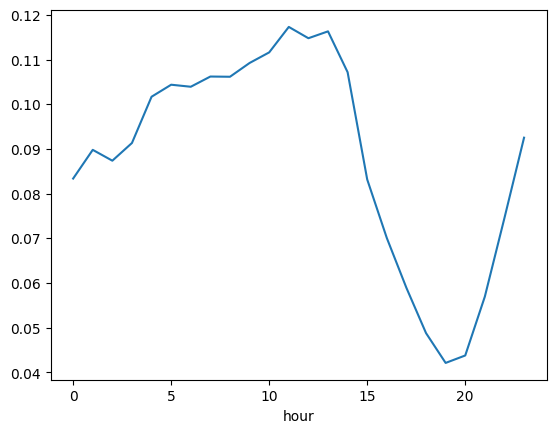

In [ ]:
train.groupby("hour")["demand"].mean().plot()

In [ ]:
train.groupby("Weather")["demand"].mean()

,demand
Weather,
Foggy,0.093372
Rainy,0.094471
Snowy,0.092581
Sunny,0.094247
Unknown,0.097218


In [ ]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    by="importance",
    ascending=False
)

print(importance.head(20))

             feature importance
0            geohash       None
1                day       None
2           RoadType       None
3      NumberofLanes       None
4      LargeVehicles       None
5          Landmarks       None
6        Temperature       None
7            Weather       None
8               hour       None
9             minute       None
10         rush_hour       None
11         temp_lane       None
12   geo_mean_demand       None
13  road_mean_demand       None


In [ ]:
print(importance)

             feature importance
0            geohash       None
1                day       None
2           RoadType       None
3      NumberofLanes       None
4      LargeVehicles       None
5          Landmarks       None
6        Temperature       None
7            Weather       None
8               hour       None
9             minute       None
10         rush_hour       None
11         temp_lane       None
12   geo_mean_demand       None
13  road_mean_demand       None


In [ ]:
model = CatBoostRegressor(
    iterations=2500,
    depth=7,
    learning_rate=0.025,
    loss_function="RMSE",
    random_seed=42,
    early_stopping_rounds=200,
    verbose=200
)

In [ ]:
# Install
!pip install catboost -q

import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# =====================
# LOAD DATA
# =====================

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# =====================
# HANDLE MISSING VALUES
# =====================

for col in ["RoadType", "Weather"]:
    train[col] = train[col].fillna("Unknown")
    test[col] = test[col].fillna("Unknown")

temp_median = train["Temperature"].median()

train["Temperature"] = train["Temperature"].fillna(temp_median)
test["Temperature"] = test["Temperature"].fillna(temp_median)

# =====================
# TIMESTAMP FEATURES
# =====================

train["timestamp"] = pd.to_datetime(train["timestamp"], format="%H:%M")
test["timestamp"] = pd.to_datetime(test["timestamp"], format="%H:%M")

for df in [train, test]:

    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute

    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    df["rush_hour"] = (
        ((df["hour"] >= 7) & (df["hour"] <= 10))
        |
        ((df["hour"] >= 17) & (df["hour"] <= 20))
    ).astype(int)

    df["temp_lane"] = (
        df["Temperature"] *
        df["NumberofLanes"]
    )

    df["road_weather"] = (
        df["RoadType"].astype(str)
        + "_" +
        df["Weather"].astype(str)
    )

# =====================
# FEATURES
# =====================

X = train.drop(
    columns=["Index", "timestamp", "demand"]
)

y = train["demand"]

X_test = test.drop(
    columns=["Index", "timestamp"]
)

# =====================
# CATEGORICAL FEATURES
# =====================

cat_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "road_weather"
]

# =====================
# TRAIN/VALID SPLIT
# =====================

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================
# MODEL
# =====================

model = CatBoostRegressor(
    iterations=1500,
    depth=8,
    learning_rate=0.04,
    loss_function="RMSE",
    eval_metric="R2",
    random_seed=42,
    early_stopping_rounds=200,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    cat_features=cat_features,
    use_best_model=True
)

# =====================
# VALIDATION SCORE
# =====================

val_preds = model.predict(X_valid)

print(
    "Validation R2:",
    r2_score(y_valid, val_preds)
)

# =====================
# FEATURE IMPORTANCE
# =====================

importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

print(
    importance.sort_values(
        "importance",
        ascending=False
    ).head(20)
)

# =====================
# TEST PREDICTIONS
# =====================

preds = model.predict(X_test)

submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": preds
})

submission.to_csv(
    "submission_v7.csv",
    index=False
)

print("submission_v7.csv saved")

0:	learn: 0.0585972	test: 0.0596349	best: 0.0596349 (0)	total: 55.1ms	remaining: 1m 22s
100:	learn: 0.8967230	test: 0.8995450	best: 0.8995450 (100)	total: 4.4s	remaining: 1m
200:	learn: 0.9150575	test: 0.9151192	best: 0.9151192 (200)	total: 9.18s	remaining: 59.3s
300:	learn: 0.9238964	test: 0.9226255	best: 0.9226255 (300)	total: 14.2s	remaining: 56.8s
400:	learn: 0.9294676	test: 0.9271669	best: 0.9271669 (400)	total: 18.5s	remaining: 50.6s
500:	learn: 0.9344374	test: 0.9304816	best: 0.9304816 (500)	total: 23s	remaining: 45.9s
600:	learn: 0.9382220	test: 0.9328794	best: 0.9328794 (600)	total: 28.4s	remaining: 42.5s
700:	learn: 0.9413206	test: 0.9348903	best: 0.9348903 (700)	total: 33s	remaining: 37.6s
800:	learn: 0.9437135	test: 0.9364846	best: 0.9364846 (800)	total: 38.3s	remaining: 33.4s
900:	learn: 0.9456118	test: 0.9374267	best: 0.9374402 (898)	total: 42.8s	remaining: 28.5s
1000:	learn: 0.9476404	test: 0.9386810	best: 0.9386826 (998)	total: 48.1s	remaining: 24s
1100:	learn: 0.949056

In [ ]:
print("Validation R2:", r2_score(y_valid, val_preds))

Validation R2: 0.941846588460324


In [ ]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": final_preds
})

submission.to_csv(
    "submission_v6.csv",
    index=False
)

from google.colab import files
files.download("submission_v7.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
2,RoadType,37.807662
0,geohash,19.488053
3,NumberofLanes,10.639790
4,LargeVehicles,9.228184
14,road_weather,6.146898
10,hour_sin,4.331697
11,hour_cos,4.180099
8,hour,3.664014
1,day,1.268249
13,temp_lane,1.245604


In [ ]:
remove_cols = [
    "Landmarks",
    "minute",
    "rush_hour"
]

In [ ]:
road_mean = train.groupby("RoadType")["demand"].mean()

train["road_mean"] = train["RoadType"].map(road_mean)
test["road_mean"] = test["RoadType"].map(road_mean)

In [ ]:
road_mean = train.groupby("RoadType")["demand"].mean()

train["road_mean"] = train["RoadType"].map(road_mean)
test["road_mean"] = test["RoadType"].map(road_mean)

In [ ]:
road_std = train.groupby("RoadType")["demand"].std()

train["road_std"] = train["RoadType"].map(road_std)
test["road_std"] = test["RoadType"].map(road_std)

In [ ]:
for df in [train, test]:

    df["geo_road"] = (
        df["geohash"].astype(str)
        + "_"
        + df["RoadType"].astype(str)
    )

In [ ]:
# Road statistics
road_mean = train.groupby("RoadType")["demand"].mean()
road_std = train.groupby("RoadType")["demand"].std()

train["road_mean"] = train["RoadType"].map(road_mean)
test["road_mean"] = test["RoadType"].map(road_mean)

train["road_std"] = train["RoadType"].map(road_std)
test["road_std"] = test["RoadType"].map(road_std)

In [ ]:
# Geo + Road interaction
for df in [train, test]:
    df["geo_road"] = (
        df["geohash"].astype(str)
        + "_"
        + df["RoadType"].astype(str)
    )

In [ ]:
cat_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Weather",
    "road_weather",
    "geo_road"
]

In [ ]:
drop_cols = [
    "Landmarks",
    "minute",
    "rush_hour"
]

In [ ]:
model = CatBoostRegressor(
    iterations=1800,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    eval_metric="R2",
    random_seed=42,
    early_stopping_rounds=200,
    verbose=100
)

In [ ]:
from sklearn.model_selection import KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train["geo_te"] = np.nan

for tr_idx, val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby("geohash")["demand"].mean()

    train.loc[val_idx, "geo_te"] = (
        val["geohash"].map(means)
    )

global_mean = train["demand"].mean()

train["geo_te"] = train["geo_te"].fillna(global_mean)

test["geo_te"] = (
    test["geohash"]
    .map(train.groupby("geohash")["demand"].mean())
    .fillna(global_mean)
)

In [ ]:
train["road_te"] = np.nan

for tr_idx, val_idx in kf.split(train):

    tr = train.iloc[tr_idx]
    val = train.iloc[val_idx]

    means = tr.groupby("RoadType")["demand"].mean()

    train.loc[val_idx, "road_te"] = (
        val["RoadType"].map(means)
    )

train["road_te"] = train["road_te"].fillna(global_mean)

test["road_te"] = (
    test["RoadType"]
    .map(train.groupby("RoadType")["demand"].mean())
    .fillna(global_mean)
)

In [ ]:
model = CatBoostRegressor(
    iterations=3000,
    depth=7,
    learning_rate=0.03,
    eval_metric="R2",
    loss_function="RMSE",
    early_stopping_rounds=300,
    random_seed=42,
    verbose=100
)

In [ ]:
print(X.columns.tolist())

['geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'hour_sin', 'hour_cos', 'rush_hour', 'temp_lane', 'road_weather']


In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# =====================
# LOAD DATA
# =====================

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# =====================
# MISSING VALUES
# =====================

for col in ["RoadType", "Weather"]:
    train[col] = train[col].fillna("Unknown")
    test[col] = test[col].fillna("Unknown")

temp_median = train["Temperature"].median()

train["Temperature"] = train["Temperature"].fillna(temp_median)
test["Temperature"] = test["Temperature"].fillna(temp_median)

# =====================
# TIME FEATURES
# =====================

train["timestamp"] = pd.to_datetime(train["timestamp"], format="%H:%M")
test["timestamp"] = pd.to_datetime(test["timestamp"], format="%H:%M")

for df in [train, test]:

    df["hour"] = df["timestamp"].dt.hour
    df["minute"] = df["timestamp"].dt.minute

    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    df["road_weather"] = (
        df["RoadType"].astype(str)
        + "_"
        + df["Weather"].astype(str)
    )

    df["temp_lane"] = (
        df["Temperature"]
        * df["NumberofLanes"]
    )

# =====================
# FEATURES
# =====================

X = train.drop(
    columns=[
        "Index",
        "timestamp",
        "demand"
    ]
)

y = train["demand"]

X_test = test.drop(
    columns=[
        "Index",
        "timestamp"
    ]
)

# =====================
# CATEGORICAL FEATURES
# =====================

cat_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "road_weather"
]

# keep only existing columns
cat_features = [
    c for c in cat_features
    if c in X.columns
]

print("Cat Features:", cat_features)

# =====================
# 5 FOLD CV
# =====================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):

    print(f"\nFold {fold+1}")

    X_train = X.iloc[tr_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[tr_idx]
    y_val = y.iloc[val_idx]

    model = CatBoostRegressor(
        iterations=1200,
        depth=8,
        learning_rate=0.04,
        loss_function="RMSE",
        eval_metric="R2",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    val_pred = model.predict(X_val)

    oof[val_idx] = val_pred

    test_preds += (
        model.predict(X_test) / 5
    )

cv_score = r2_score(y, oof)

print("\nCV R2 =", cv_score)

# =====================
# SUBMISSION
# =====================

submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": test_preds
})

submission.to_csv(
    "submission_v9.csv",
    index=False
)

print("submission_v9.csv saved")

Cat Features: ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'road_weather']

Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

CV R2 = 0.9387281584587385
submission_v9.csv saved


In [ ]:
for df in [train, test]:

    df["geo_road"] = (
        df["geohash"].astype(str)
        + "_"
        + df["RoadType"].astype(str)
    )

In [ ]:
cat_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "road_weather",
    "geo_road"
]

In [ ]:
print(X.columns.tolist())

['geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'hour_sin', 'hour_cos', 'road_weather', 'temp_lane']


In [ ]:
train["geo_road"] = train["geohash"].astype(str) + "_" + train["RoadType"].astype(str)
test["geo_road"] = test["geohash"].astype(str) + "_" + test["RoadType"].astype(str)

In [ ]:
# Create feature
train["geo_road"] = (
    train["geohash"].astype(str)
    + "_"
    + train["RoadType"].astype(str)
)

test["geo_road"] = (
    test["geohash"].astype(str)
    + "_"
    + test["RoadType"].astype(str)
)

# Rebuild X and X_test
X = train.drop(
    columns=["Index", "timestamp", "demand"]
)

X_test = test.drop(
    columns=["Index", "timestamp"]
)

print(X.columns.tolist())

['geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'hour', 'minute', 'hour_sin', 'hour_cos', 'road_weather', 'temp_lane', 'geo_road']


In [ ]:
cat_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather",
    "road_weather",
    "geo_road"
]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    cat_features=cat_features,
    use_best_model=True
)

preds = model.predict(X_valid)

print(
    "Validation R2:",
    r2_score(y_valid, preds)
)

Validation R2: 0.9404892230666042
